# Практическая работа №5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, recall_score, precision_score
import warnings

warnings.filterwarnings('ignore')

## EDA

In [2]:
data = pd.read_csv("../data\Smartphone_Dependence.csv")
data

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          6681 non-n

In [4]:
data.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [5]:
data['addiction_level'] = data['addiction_level'].fillna('None')
print(data['addiction_level'].unique())

<StringArray>
['None', 'Mild', 'Moderate', 'Severe']
Length: 4, dtype: str


Можно заметить, что `transaction_id` и `user_id` представляют собой просто счётсчкики, которые не несут информацию и служат индексами строк - их можно удалить

In [6]:
data = data.drop(columns = ['transaction_id', 'user_id'])

Теперь остается перекодировать `str` признаки

In [7]:
str_atr = ['gender', 'stress_level', 'academic_work_impact', 'addiction_level']
all_mappings = {}

data['addiction_level'] = data['addiction_level'].fillna('None')

print(data['addiction_level'].unique())

for col in str_atr:
    unique_vals = sorted(data[col].unique())
    
    col_map = {val: idx for idx, val in enumerate(unique_vals)}
    all_mappings[col] = col_map
    
    data[col] = data[col].map(col_map)

data.info()

<StringArray>
['None', 'Mild', 'Moderate', 'Severe']
Length: 4, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      7500 non-null   int64  
 1   gender                   7500 non-null   int64  
 2   daily_screen_time_hours  7500 non-null   float64
 3   social_media_hours       7500 non-null   float64
 4   gaming_hours             7500 non-null   float64
 5   work_study_hours         7500 non-null   float64
 6   sleep_hours              7500 non-null   float64
 7   notifications_per_day    7500 non-null   int64  
 8   app_opens_per_day        7500 non-null   int64  
 9   weekend_screen_time      7500 non-null   float64
 10  stress_level             7500 non-null   int64  
 11  academic_work_impact     7500 non-null   int64  
 12  addiction_level          7500 non-null   int64  
 13  addicted_label

In [8]:
print(data['addiction_level'].unique())

[2 0 1 3]


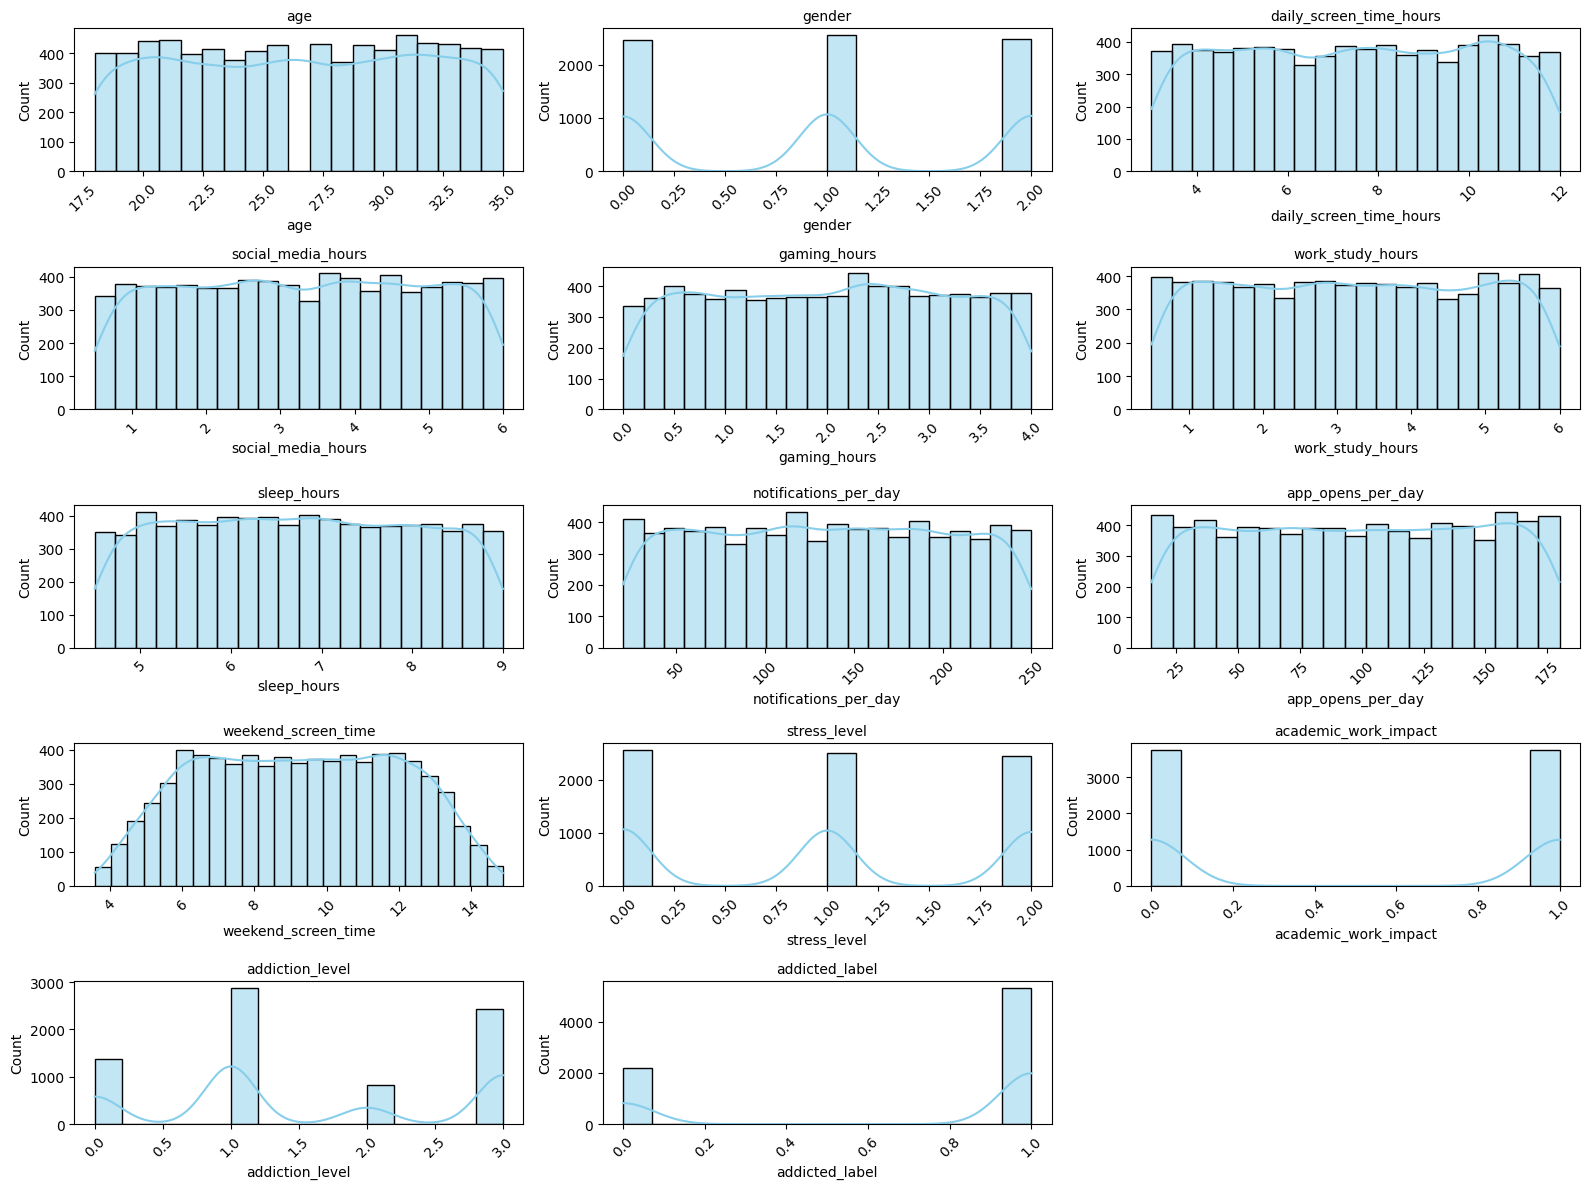

In [9]:
fig, axes = plt.subplots(5, 3, figsize=(16, 12))
axes = axes.flatten()
cols = data.columns

for i, col in enumerate(cols):
    if data[col].dtype in ['float64', 'int64']:
        sns.histplot(data[col], ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cols[:14]), 15):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Смотря на графики, выдно что выбросов нет. Более того, неперекодированные признаки имеют равномерное распределение

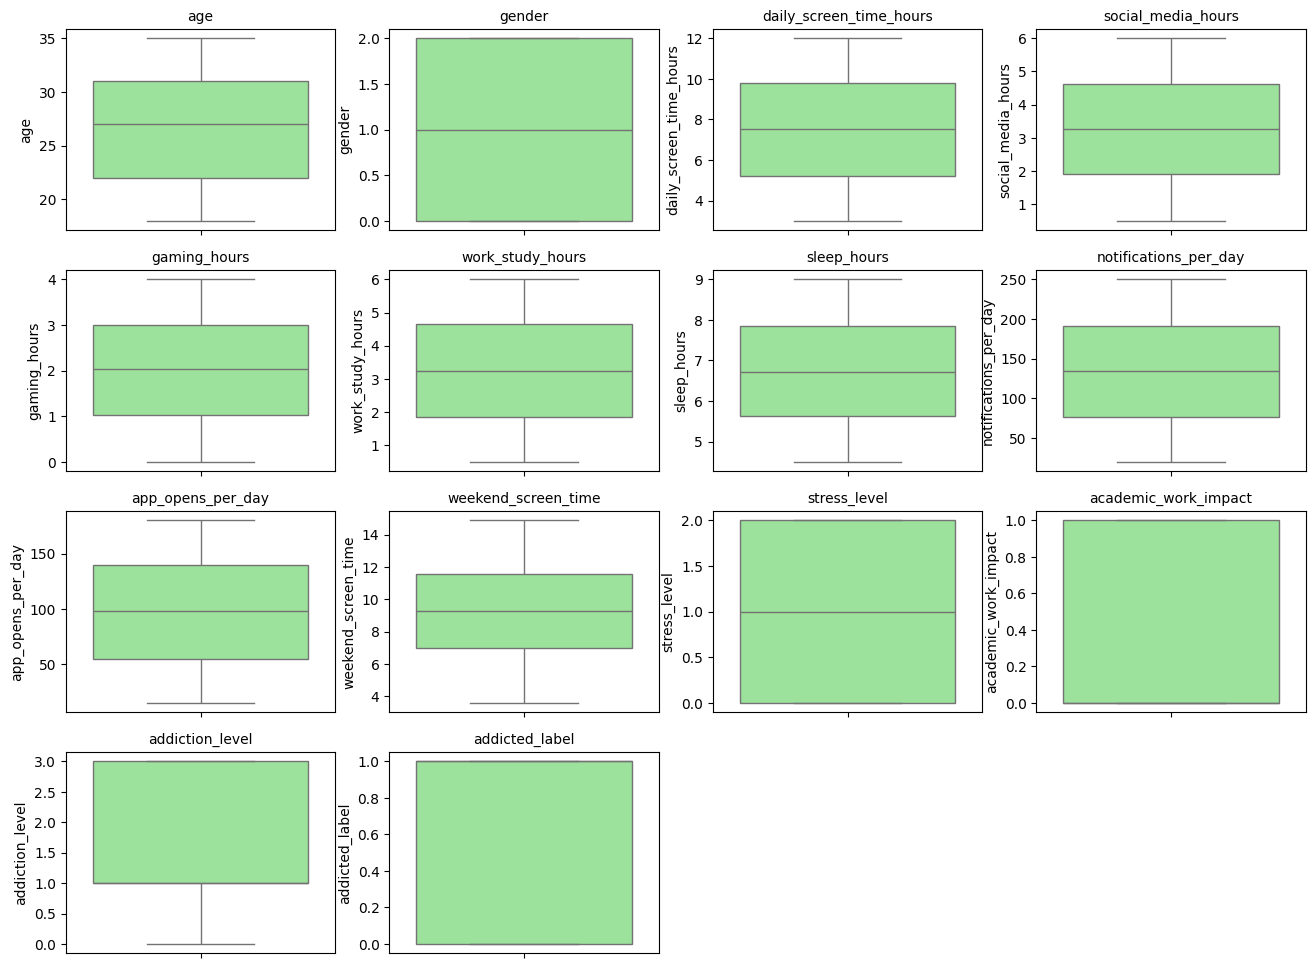

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=data[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cols), 16):
    axes[j].set_visible(False)

Boxpot так же подтверждают чистоту данных 

addicted_label             0.474073
daily_screen_time_hours    0.256684
weekend_screen_time        0.246567
social_media_hours         0.244918
sleep_hours                0.023815
age                        0.019345
gender                     0.011793
app_opens_per_day          0.008769
work_study_hours           0.004268
stress_level              -0.000910
gaming_hours              -0.002354
academic_work_impact      -0.010995
notifications_per_day     -0.012030
Name: addiction_level, dtype: float64


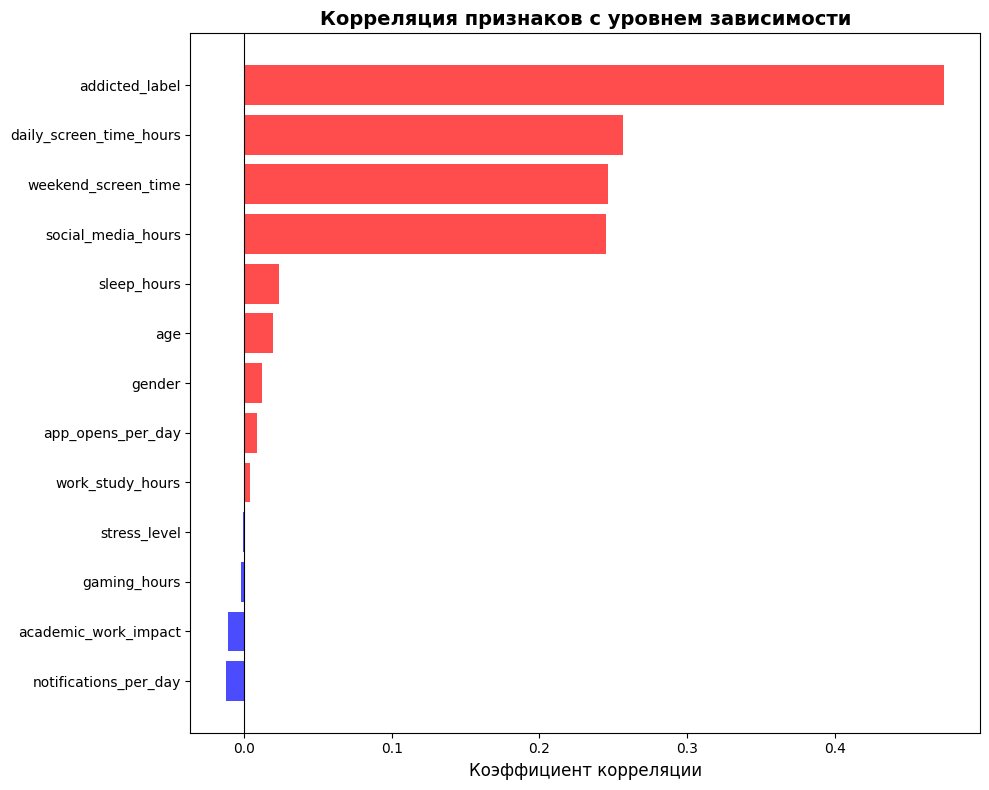

In [11]:
corr_matrix = data[cols].corr()

target_corr = corr_matrix['addiction_level'].drop('addiction_level').sort_values(ascending=False)
print(target_corr)

plt.figure(figsize=(10, 8))
colors = ['red' if x > 0 else 'blue' for x in target_corr.values]
bars = plt.barh(target_corr.index, target_corr.values, color=colors, alpha=0.7)
plt.xlabel('Коэффициент корреляции', fontsize=12)
plt.title('Корреляция признаков с уровнем зависимости', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

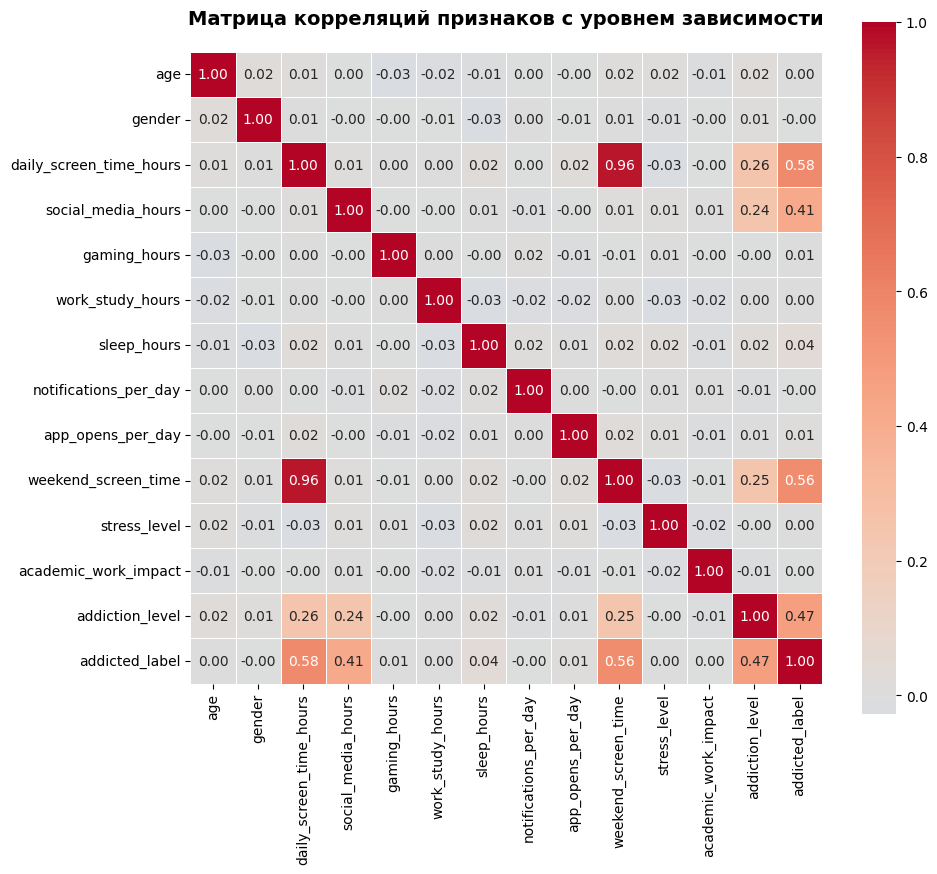

In [12]:
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=.5, square=True, cbar_kws={"shrink": .8})
plt.title('Матрица корреляций признаков с уровнем зависимости', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Из тепловой карты видно, что:

- `addicted_label` сильно коррелирует `target` (так как является его булевым предствелением)
- Наибольшие корреляции `traget` с `daily_screen_time_hours`, `weekend_screen_time`, `social_media_hours`
- Присутствует коллинеарность между `weekend_screen_time` и `daily_screen_time_hours`
=
Все остальыне корреляции незначительны

## Тренировка

In [13]:
def calculate_metrics(y_true, y_pred):
    return {
        'F1': f1_score(y_true, y_pred, average="weighted"),
        'Accuracy': accuracy_score(y_true, y_pred), 
        'Precision': precision_score(y_true, y_pred, average="weighted"),
        'Recall': recall_score(y_true, y_pred, average="weighted")
    }

In [14]:
X = data.drop(columns = ["addiction_level", "addicted_label"])
y = data["addiction_level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print(X_train_scaled.shape, X_test_scaled.shape)

(6000, 12) (1500, 12)


In [15]:
y_train.value_counts()

addiction_level
1    2299
3    1947
0    1099
2     655
Name: count, dtype: int64

Присутствует дизбаланс классов

In [16]:
oversample = SMOTE()

X_train_bal, y_train_bal = oversample.fit_resample(X_train_scaled, y_train)
y_train_bal.value_counts()

addiction_level
3    2299
1    2299
2    2299
0    2299
Name: count, dtype: int64

In [17]:
model = LogisticRegression()

Logreg = model.fit(X_train_bal, y_train_bal) 

coefficients = pd.DataFrame({
    'feature': X.columns,
    **{f'coef_{cls}': model.coef_[i] for i, cls in enumerate(model.classes_)}
})

coefficients

,feature,coef_0,coef_1,coef_2,coef_3
0,age,-0.048875,0.027166,-0.074189,0.095898
1,gender,0.032992,-0.071184,0.067460,-0.029268
2,daily_screen_time_hours,-1.101044,1.780829,-2.571116,1.891331
3,social_media_hours,-1.121877,1.201545,-1.533149,1.453481
4,gaming_hours,-0.016471,0.018836,-0.023762,0.021396
5,work_study_hours,-0.014490,-0.014153,0.069280,-0.040638
6,sleep_hours,-0.059659,0.052494,-0.073579,0.080744
7,notifications_per_day,-0.021104,0.019062,0.051107,-0.049065
8,app_opens_per_day,-0.017266,0.023629,-0.046426,0.040062
9,weekend_screen_time,0.074901,0.044066,-0.264174,0.145206


Видно, что наибольший вес имеют `daily_screen_time_hours` и `social_media_hours`, что весьма ожидаемо из предыдущего анализа признаков

In [18]:
y_test_pred = Logreg.predict(X_test)

print(confusion_matrix(y_test, y_test_pred))

calculate_metrics(y_test, y_test_pred)

[[  0 209   0  65]
 [  0 385   0 190]
 [  0 114   0  50]
 [  0 341   0 146]]


{'F1': 0.2828218145724579,
 'Accuracy': 0.354,
 'Precision': 0.24579228026269342,
 'Recall': 0.354}

Модель вообще не смогла угадать ни 1 тип, ни 3 (0 успешных предсказаний), метрики так же плохие. Данная модель не подходит для этой задачи классификации

### Опитимазция с помощью GridSearchCV

In [19]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg', 'sag'],
    'max_iter': [1000]
}

grid_lr = GridSearchCV(
    LogisticRegression(),
    param_grid_lr,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)


grid_lr.fit(X_train_bal, y_train_bal)
best_lr = grid_lr.best_estimator_

In [20]:
y_pred_lr = best_lr.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_lr))
calculate_metrics(y_test, y_pred_lr)

[[130  40  99   5]
 [ 77 223  19 256]
 [ 57   7 100   0]
 [ 24 180  27 256]]


{'F1': 0.4703352562793901,
 'Accuracy': 0.4726666666666667,
 'Precision': 0.4778058954723089,
 'Recall': 0.4726666666666667}

Этот результат намного лучше, стал угадываться 1 класс, но просело угадывание 2 класса. Все равно этот результат намного лучше предыдущего, но все равно очень плохой для этой задачи. Скорее всего, зависмости являются нелинейными, и поэтому логистическая регрессия плохо работает на этих данных

In [21]:
coef_df = pd.DataFrame(
    best_lr.coef_.T,
    columns=[f'Class_{i}' for i in range(4)],
    index=X.columns
)
coef_df['max_abs_coef'] = coef_df.abs().max(axis=1)
coef_df = coef_df.sort_values('max_abs_coef', ascending=False)

print("\nТоп-5 наиболее важных признаков (по модулю коэффициента):")
print(coef_df.head())


Топ-5 наиболее важных признаков (по модулю коэффициента):
                          Class_0   Class_1   Class_2   Class_3  max_abs_coef
daily_screen_time_hours -1.140686  1.835500 -2.638786  1.943972      2.638786
social_media_hours      -1.131863  1.213111 -1.546924  1.465676      1.546924
weekend_screen_time      0.104663  0.004791 -0.217480  0.108026      0.217480
age                     -0.049574  0.028010 -0.075359  0.096922      0.096922
sleep_hours             -0.060037  0.052879 -0.074334  0.081493      0.081493


## Дерево

In [22]:
tree_default = DecisionTreeClassifier(random_state=42)
tree_default.fit(X_train_bal, y_train_bal)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [23]:
y_pred_tree_default = tree_default.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_lr))
calculate_metrics(y_test, y_pred_lr)

[[130  40  99   5]
 [ 77 223  19 256]
 [ 57   7 100   0]
 [ 24 180  27 256]]


{'F1': 0.4703352562793901,
 'Accuracy': 0.4726666666666667,
 'Precision': 0.4778058954723089,
 'Recall': 0.4726666666666667}

Этот результат уже лучше логистической регрессии, имеются значительныеи ошибки

[Text(0.5089285714285714, 0.9, 'daily_screen_time_hours <= 0.177\ngini = 0.75\nsamples = 9196\nvalue = [2299, 2299, 2299, 2299]\nclass = None'),
 Text(0.2857142857142857, 0.7, 'social_media_hours <= 0.465\ngini = 0.693\nsamples = 6235\nvalue = [2291, 952, 2299, 693]\nclass = Moderate'),
 Text(0.39732142857142855, 0.8, 'True  '),
 Text(0.14285714285714285, 0.5, 'daily_screen_time_hours <= -0.582\ngini = 0.565\nsamples = 4952\nvalue = [2291, 361, 2299, 1]\nclass = Moderate'),
 Text(0.07142857142857142, 0.3, 'daily_screen_time_hours <= -0.915\ngini = 0.466\nsamples = 3644\nvalue = [1349, 0, 2295, 0]\nclass = Moderate'),
 Text(0.03571428571428571, 0.1, '\n  (...)  \n'),
 Text(0.10714285714285714, 0.1, '\n  (...)  \n'),
 Text(0.21428571428571427, 0.3, 'work_study_hours <= 1.634\ngini = 0.405\nsamples = 1308\nvalue = [942, 361, 4, 1]\nclass = None'),
 Text(0.17857142857142858, 0.1, '\n  (...)  \n'),
 Text(0.25, 0.1, '\n  (...)  \n'),
 Text(0.42857142857142855, 0.5, 'age <= -1.448\ngini = 0.4

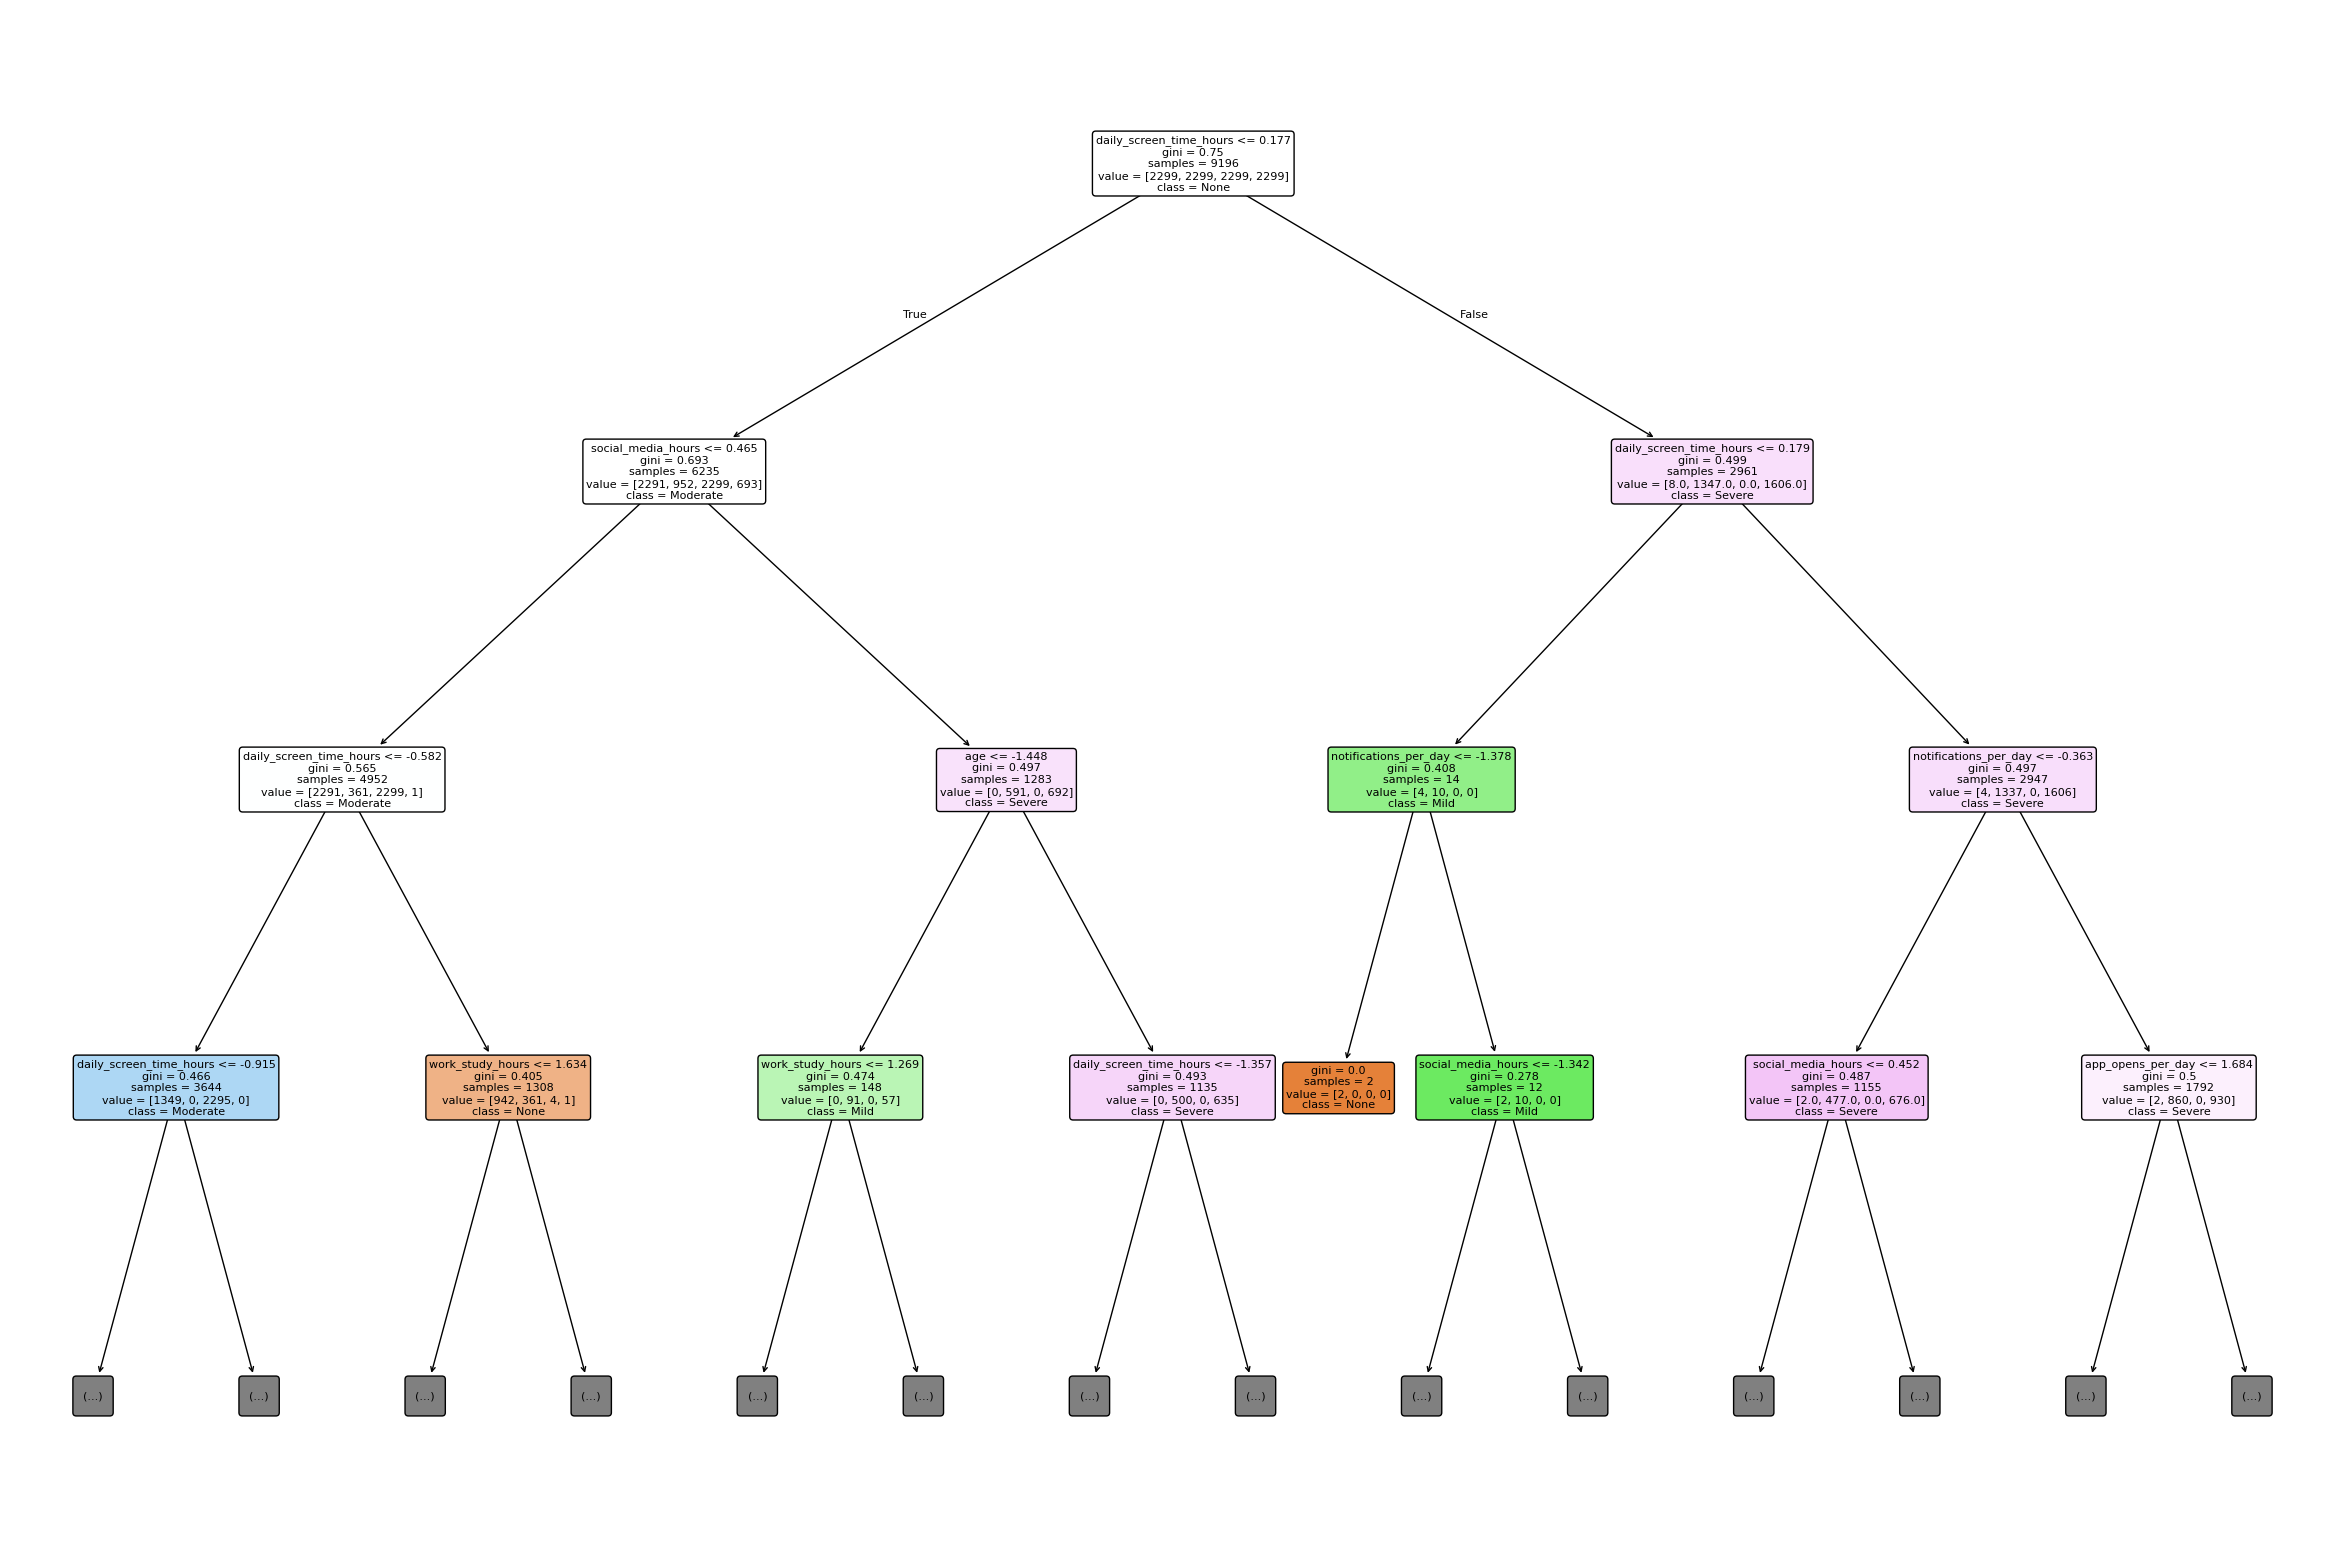

In [25]:
plt.figure(figsize=(30, 20))
plot_tree(
    tree_default,
    feature_names=X.columns,
    class_names=['None', 'Mild', 'Moderate', 'Severe'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

### Оптимизация дерева с GridSearchCV 

In [26]:
param_grid_tree = {
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 4, 8, 16],
    'criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

In [27]:
grid_tree.fit(X_train_bal, y_train_bal)
best_tree = grid_tree.best_estimator_

In [28]:
y_pred_tree_best = best_tree.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_tree_best))
calculate_metrics(y_test, y_pred_tree_best)

[[149  34  91   0]
 [ 62 261   0 252]
 [ 72   0  92   0]
 [  0 238   0 249]]


{'F1': 0.4999467715681094,
 'Accuracy': 0.5006666666666667,
 'Precision': 0.5002120612172521,
 'Recall': 0.5006666666666667}

Метрикик еще немного улчушились, и некоторые ошибки свелись к 0, что говорит о том, что модель перестала делать такие ошибки

[Text(0.5793269230769231, 0.9166666666666666, 'daily_screen_time_hours <= 0.192\nentropy = 2.0\nsamples = 9196\nvalue = [2299, 2299, 2299, 2299]\nclass = None'),
 Text(0.3076923076923077, 0.75, 'social_media_hours <= 0.465\nentropy = 1.832\nsamples = 6271\nvalue = [2299.0, 972.0, 2299.0, 701.0]\nclass = None'),
 Text(0.4435096153846154, 0.8333333333333333, 'True  '),
 Text(0.15384615384615385, 0.5833333333333334, 'daily_screen_time_hours <= -0.575\nentropy = 1.311\nsamples = 4971\nvalue = [2299, 372, 2299, 1]\nclass = None'),
 Text(0.07692307692307693, 0.4166666666666667, 'daily_screen_time_hours <= -0.915\nentropy = 0.952\nsamples = 3658\nvalue = [1359, 0, 2299, 0]\nclass = Moderate'),
 Text(0.038461538461538464, 0.25, 'work_study_hours <= -1.005\nentropy = 0.923\nsamples = 2616\nvalue = [885, 0, 1731, 0]\nclass = Moderate'),
 Text(0.019230769230769232, 0.08333333333333333, '\n  (...)  \n'),
 Text(0.057692307692307696, 0.08333333333333333, '\n  (...)  \n'),
 Text(0.11538461538461539, 

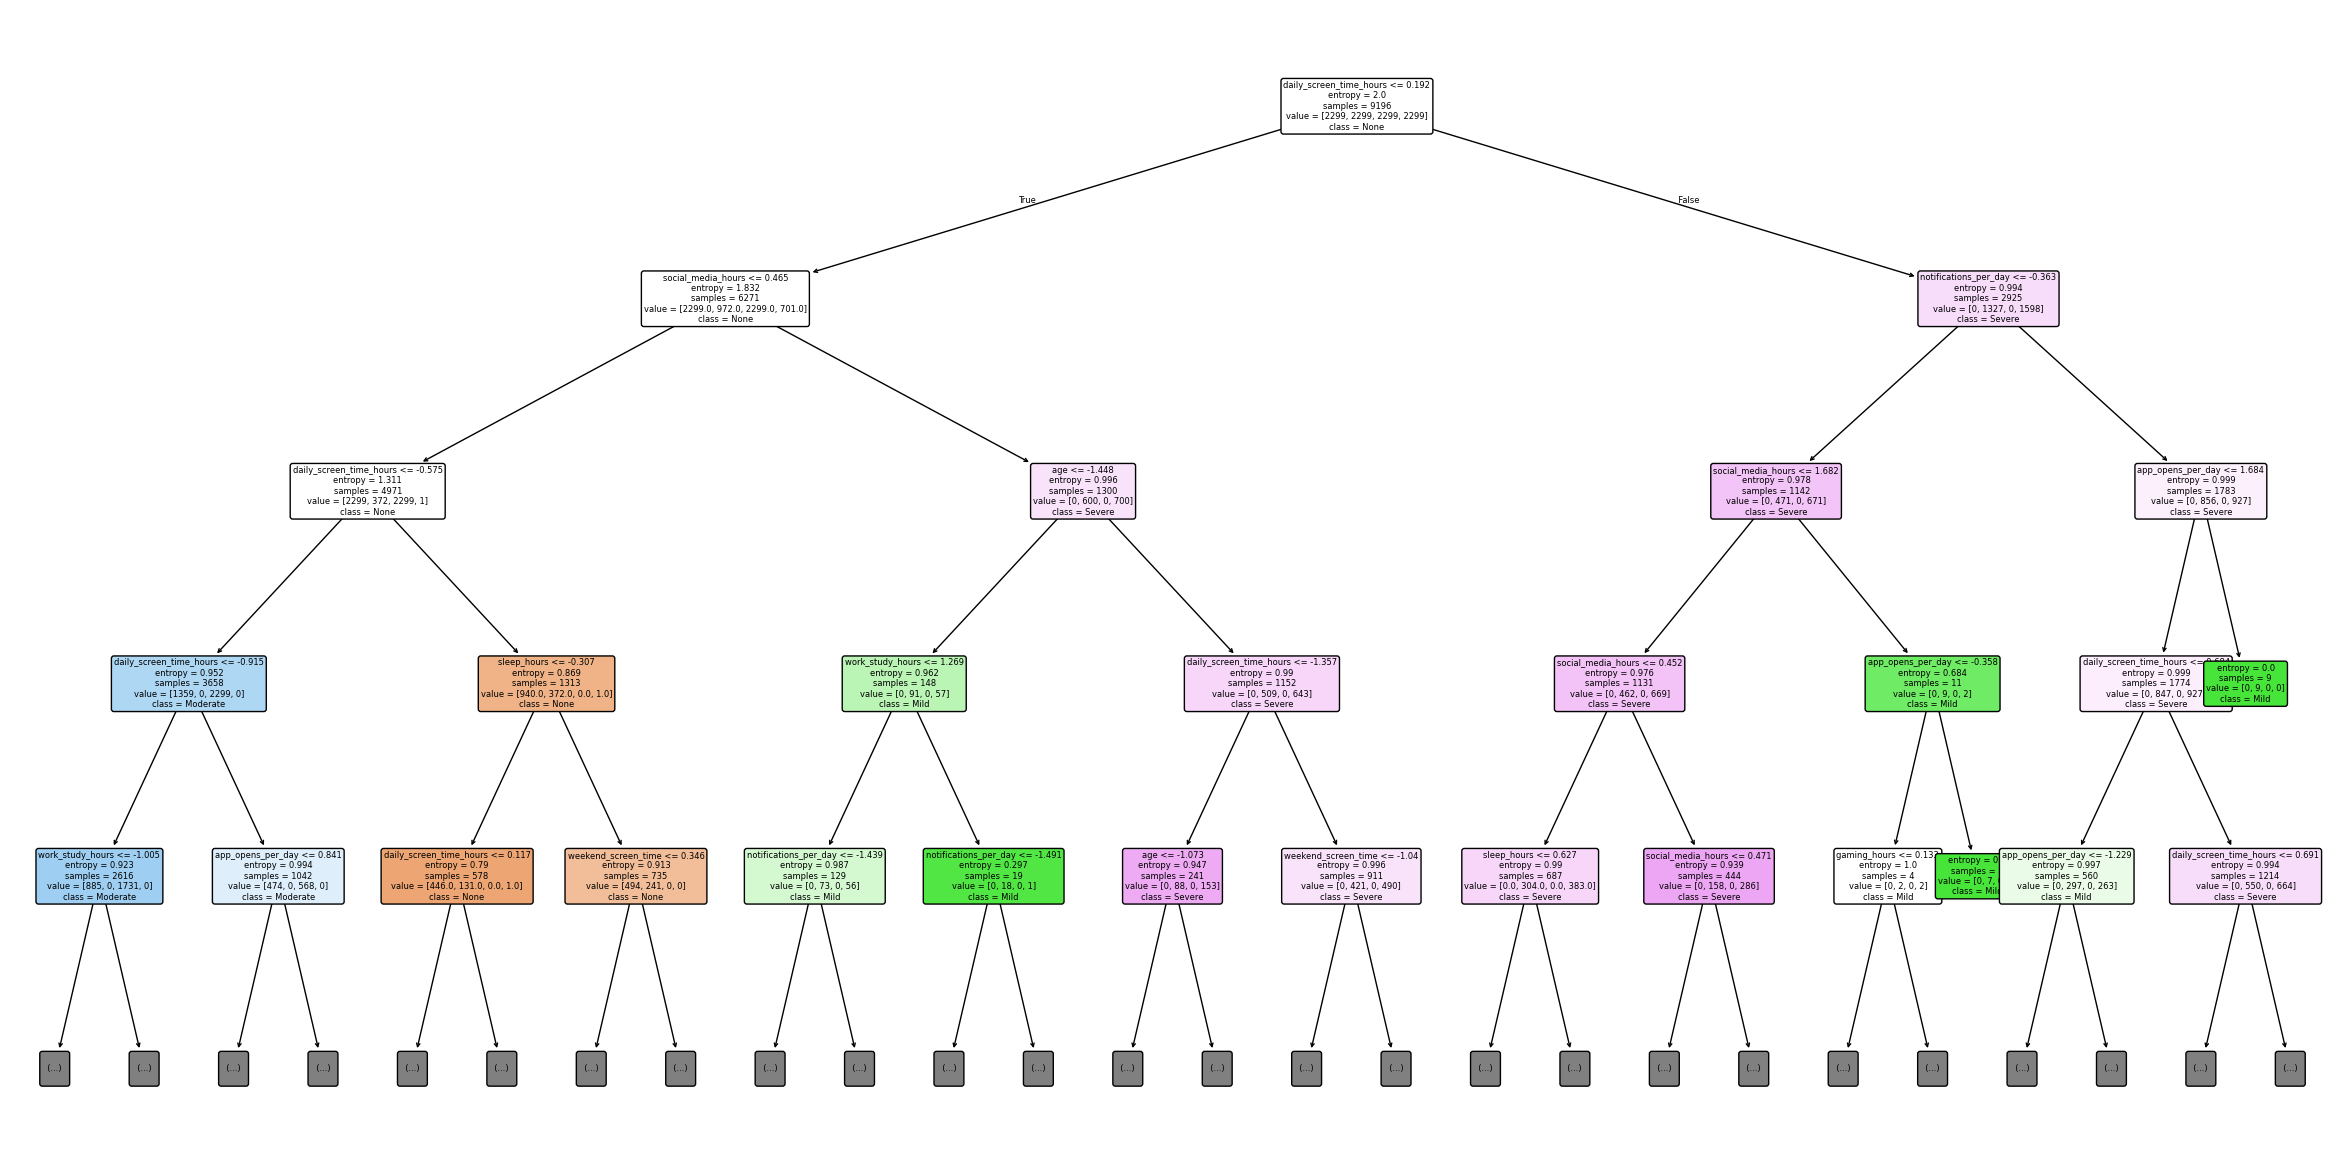

In [43]:
plt.figure(figsize=(30, 15))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=['None', 'Mild', 'Moderate', 'Severe'],
    filled=True,
    rounded=True,
    fontsize=6,
    max_depth=4
)

**При анализе использовалась более полное дерево с большей глубиной, но она почти нечитаемая, поэтому в конечной работе оставлена глубина 4 для наглядной визуализации**

In [38]:
feature_importance_best = pd.DataFrame({
    'feature': X.columns,
    'importance': best_tree.feature_importances_
}).sort_values('importance', ascending=False)

print("\nВажность признаков (после настройки):")
print(feature_importance_best)


Важность признаков (после настройки):
                    feature  importance
2   daily_screen_time_hours    0.373175
3        social_media_hours    0.256631
4              gaming_hours    0.053089
7     notifications_per_day    0.052254
8         app_opens_per_day    0.051655
6               sleep_hours    0.051034
5          work_study_hours    0.050697
9       weekend_screen_time    0.039981
0                       age    0.039089
1                    gender    0.014032
10             stress_level    0.011874
11     academic_work_impact    0.006488


## Анализ зависимостей

    daily_screen_time_hours <= 7.5 → низкий уровень зависимости (None/Mild)
    daily_screen_time_hours > 7.5 → высокий уровень зависимости (Moderate/Severe)

    social_media_hours <= 3.2 → Moderate
    social_media_hours > 3.2 → Severe

    weekend_screen_time > 10.5 → усиливает Severe
    gaming_hours > 2.5 → смещает к Moderate/Severe


| Комбинация признаков | Результат |
|---------------------|-----------|
| Экранное время > 7.5ч + соцсети > 3.2ч | **Severe** (сильная зависимость) |
| Экранное время > 7.5ч + соцсети ≤ 3.2ч | **Moderate** (умеренная) |
| Экранное время ≤ 7.5ч | **None/Mild** (слабая/отсутствует) |
| Экранное время > 7.5ч + выходные > 10.5ч | **Severe** (усиление) |

**Нелинейные эффекты**

    Пороговый эффект: резкий скачок зависимости происходит при 7.5 часах экранного времени (не линейно)
    Эффект взаимодействия: влияние соцсетей зависит от общего экранного времени (при низком экранном времени соцсети не страшны)
    Эффект насыщения: после 10-11 часов экранного времени добавление часов почти не меняет уровень зависимости